<a href="https://colab.research.google.com/github/TanyaGupta37/ML-Lab/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

In [4]:
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

red['type'] = 0
white['type'] = 1

df = pd.concat([red, white], ignore_index=True)

df['label'] = (df['quality'] >= 6).astype(int)

X = df.drop(columns=['quality', 'label']).values
y = df['label'].values

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (6497, 12)
Target Shape: (6497,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (5197, 12)
Testing Shape: (1300, 12)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape to (samples, timesteps, channels) — required for Conv1D
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print("Reshaped Training Shape:", X_train.shape)

Reshaped Training Shape: (5197, 12, 1)


In [7]:
model = Sequential()

# Convolution Layer 1
model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=(12, 1)))

# Pooling Layer 1
model.add(MaxPooling1D(pool_size=2))

# Convolution Layer 2
model.add(Conv1D(64, kernel_size=3, activation='relu'))

# Pooling Layer 2 (global since feature dim is now small)
model.add(MaxPooling1D(pool_size=1))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,169 (121.75 KB)

 Trainable params: 31,169 (121.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6651 - loss: 0.5965 - val_accuracy: 0.7135 - val_loss: 0.5368
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7207 - loss: 0.5346 - val_accuracy: 0.7423 - val_loss: 0.5084
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7433 - loss: 0.5123 - val_accuracy: 0.7625 - val_loss: 0.4872
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7515 - loss: 0.4988 - val_accuracy: 0.7740 - val_loss: 0.4793
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7652 - loss: 0.4895 - val_accuracy: 0.7712 - val_loss: 0.4781
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7700 - loss: 0.4876 - val_accuracy: 0.7808 - val_loss: 0.4662
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7722 - loss: 0.4844 - val_accuracy: 0.7644 - val_loss: 0.4690
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7638 - loss: 0.4820 - val_accuracy: 0.7702 - val_

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7546 - loss: 0.5133
Test Accuracy: 0.7546153664588928
Test Loss: 0.5133345127105713


In [12]:
predictions = model.predict(X_test)
predicted_labels = (predictions > 0.5).astype(int)

print(predicted_labels[:10].flatten())

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[1 0 1 0 0 1 1 1 0 1]


In [13]:
cm = confusion_matrix(y_test, predicted_labels)

print(cm)

[[323 128]
 [191 658]]


In [14]:
print(classification_report(y_test, predicted_labels, target_names=['Bad (0)', 'Good (1)']))

              precision    recall  f1-score   support

     Bad (0)       0.63      0.72      0.67       451
    Good (1)       0.84      0.78      0.80       849

    accuracy                           0.75      1300
   macro avg       0.73      0.75      0.74      1300
weighted avg       0.76      0.75      0.76      1300



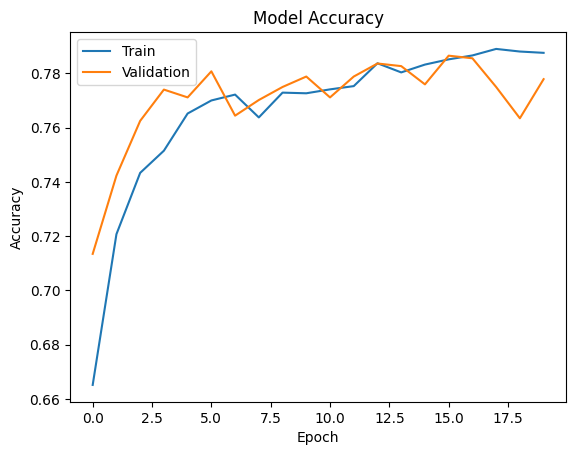

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])
plt.show()

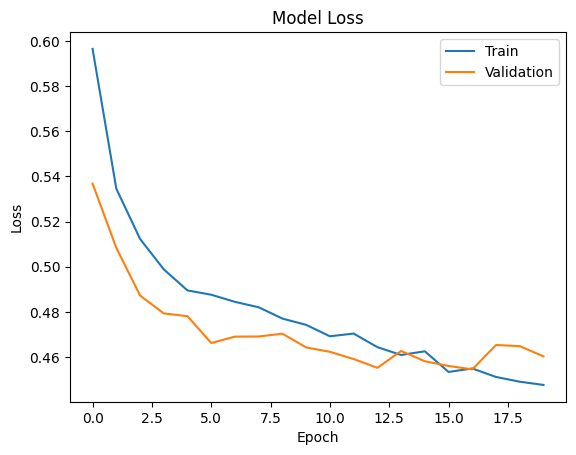

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])
plt.show()